In [79]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

In [80]:
dataset = pd.read_csv('property_purchase_cleaned.csv')
dataset.head()

,Unnamed: 0,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,garage,garden,crime_cases_reported,...,location_UAE_Dubai,location_UK_Birmingham,location_UK_Liverpool,location_UK_London,location_UK_Manchester,location_USA_Chicago,location_USA_Houston,location_USA_Los Angeles,location_USA_New York,location_USA_San Francisco
0,0,2862,1141712,2005,0,5,5,0,1,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,5642,848469,2002,5,4,2,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2275,910391,2004,2,3,3,1,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,4333,866338,2012,5,2,2,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,3365,675228,1960,0,3,2,1,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:
X = dataset.drop('decision', axis = 1)
y = dataset['decision']

print(y)

0        1
1        0
2        1
3        0
4        0
        ..
24995    1
24996    0
24997    1
24998    0
24999    0
Name: decision, Length: 25000, dtype: int64


In [82]:
#check for multicollinearity
X.corr()
X.drop('Unnamed: 0', axis = 1, inplace = True)

In [83]:
#train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<Axes: >

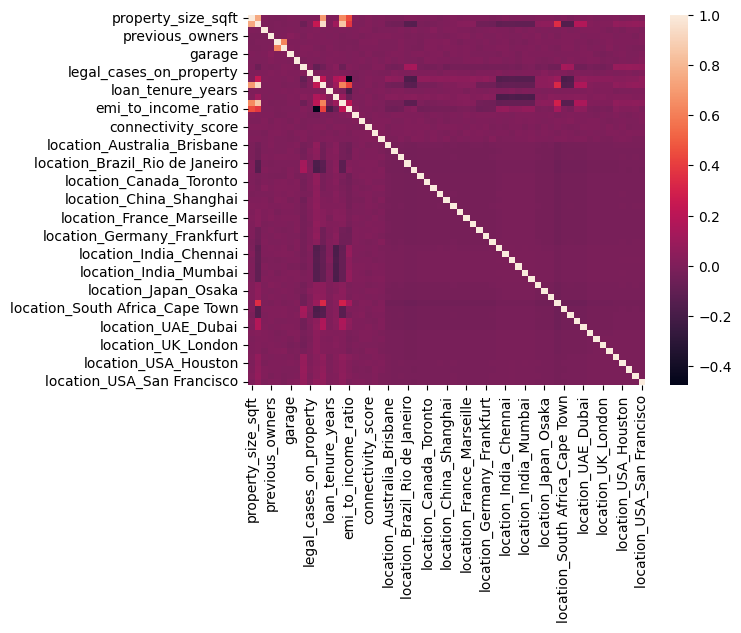

In [84]:
#heatmap for multicollinearity
sns.heatmap(x_train.corr())

In [85]:
#eliminate multicollinearity
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range (len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [86]:
corr_features = correlation(x_train, .85)

In [87]:
x_train.drop(corr_features, axis= 1, inplace = True)
x_test.drop(corr_features, axis= 1, inplace = True)

In [88]:
#standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [89]:
#model creation
from sklearn.linear_model import LogisticRegression
log_regressor = LogisticRegression()
log_regressor.fit(x_train_scaled, y_train)
y_pred = log_regressor.predict(x_test_scaled)

In [90]:
print(y_pred)

[0 0 1 ... 0 0 0]


In [91]:
#check accuracy
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
cf_log = confusion_matrix(y_test, y_pred)
score_log = accuracy_score(y_test, y_pred)
report_log = classification_report(y_test, y_pred)

print(cf_log)
print(score_log)
print(report_log)

[[4670  188]
 [ 190 1202]]
0.93952
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4858
           1       0.86      0.86      0.86      1392

    accuracy                           0.94      6250
   macro avg       0.91      0.91      0.91      6250
weighted avg       0.94      0.94      0.94      6250



In [92]:
log_regressor.predict_proba(x_test_scaled)

array([[9.99983748e-01, 1.62522686e-05],
       [9.99998221e-01, 1.77870181e-06],
       [2.92397360e-02, 9.70760264e-01],
       ...,
       [9.12051066e-01, 8.79489344e-02],
       [9.99999177e-01, 8.22916197e-07],
       [1.00000000e+00, 2.04047314e-10]], shape=(6250, 2))

Hyperparameter Tuning with Grid CV

In [93]:
#hyperparameter Tuning
model = LogisticRegression()
penalty = ['l1', 'l2', 'elasticnet']
c_values = [100,10,1,.1,.01]
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
param = dict(penalty = penalty, C = c_values, solver = solver)
param

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1, 0.1, 0.01],
 'solver': ['lbfgs',
  'liblinear',
  'newton-cg',
  'newton-cholesky',
  'sag',
  'saga']}

In [94]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
cv = StratifiedKFold()
grid = GridSearchCV(estimator= model, param_grid= param, scoring = 'accuracy',cv= cv, n_jobs= -1, error_score= 0)

grid.fit(x_train_scaled, y_train)
grid

c:\Users\Shubham\Desktop\Data Science Prep\DS Projects\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
225 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to 0.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Shubham\Desktop\Data Science Prep\DS Projects\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Shubham\Desktop\Data Science Prep\DS Projects\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Use

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [95]:
#check for best parameter
grid.best_params_

{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}

In [96]:
#predict values with grid
y_pred_grid = grid.predict(x_test_scaled)
y_pred_grid

array([0, 0, 1, ..., 0, 0, 0], shape=(6250,))

In [97]:
#check scores
cf_grid = confusion_matrix(y_test, y_pred_grid)
score_grid = accuracy_score(y_test, y_pred_grid)
report_grid = classification_report(y_test, y_pred_grid)

print(cf_grid)
print(score_grid)
print(report_grid)

[[4669  189]
 [ 190 1202]]
0.93936
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4858
           1       0.86      0.86      0.86      1392

    accuracy                           0.94      6250
   macro avg       0.91      0.91      0.91      6250
weighted avg       0.94      0.94      0.94      6250



Hyperparameter tuning with random CV

In [98]:
from sklearn.model_selection import RandomizedSearchCV
randomCV = RandomizedSearchCV(estimator= model, param_distributions= param, scoring = 'accuracy',cv= 5)

randomCV.fit(x_train_scaled, y_train)


c:\Users\Shubham\Desktop\Data Science Prep\DS Projects\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Shubham\Desktop\Data Science Prep\DS Projects\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Shubham\Desktop\Data Science Prep\DS Projects\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'pe

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [101]:
#predict with randomized Search CV
y_pred_random = randomCV.predict(x_test_scaled)
y_pred_random

array([0, 0, 1, ..., 0, 0, 0], shape=(6250,))

In [102]:
#check scores with Randomized CV
cf_random = confusion_matrix(y_test, y_pred_random)
score_random = accuracy_score(y_test, y_pred_random)
report_random = classification_report(y_test, y_pred_random)

print(cf_random)
print(score_random)
print(report_random)

[[4669  189]
 [ 190 1202]]
0.93936
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4858
           1       0.86      0.86      0.86      1392

    accuracy                           0.94      6250
   macro avg       0.91      0.91      0.91      6250
weighted avg       0.94      0.94      0.94      6250



#comparing results across all models



In [103]:
final_results = {'Model' :[
                    'Logistic Regression',
                    'Grid Search Logistic Regression',
                    'Grandomized Search Logsitc Regression',
                    ],
                "accuracy": [
                    score_log,
                    score_grid,
                    score_random 
                ]}

comparison_df = pd.DataFrame(final_results)
print(comparison_df)

                                   Model  accuracy
0                    Logistic Regression   0.93952
1        Grid Search Logistic Regression   0.93936
2  Grandomized Search Logsitc Regression   0.93936


Almost models have similar accuracy